# Import libraries

In [169]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load annotation

### Load full ground truth

In [170]:
with open('../data/charades/annotations/charades.json', 'r') as f:
  gt = json.load(f)

rows_gt = []
for video_id, info in gt['database'].items():
  for s in info['annotations']:
    rows_gt.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label']
    })

gt_df = pd.DataFrame(rows_gt)
gt_df.head()

,video_id,start,end,label
0,7UPGT,16.0,22.2,Someone is laughing
1,7UPGT,16.0,22.2,Someone is smiling
2,7UPGT,15.0,20.0,Closing a refrigerator
3,7UPGT,14.0,23.0,Holding a cup/glass/bottle of something
4,7UPGT,0.0,5.0,Opening a refrigerator


In [171]:
gt_df.shape

(66500, 4)

### Select only some classes for training / testing the model

In [ ]:
# Create sample classes and save them to a file
sample_classes = sorted(gt_df['label'].value_counts()[-10:].index.tolist()) # Select the 10 least frequent classes
with open('../data/charades/annotations/sample_category_idx.txt', 'w') as f:
    for action in sample_classes:
        f.write(action + '\n')

# Filter rows with labels in it
gt_df_sample = gt_df[gt_df['label'].isin(sample_classes)].copy()

# Save sample annotations to JSON file
output = {
    "version": "Charades_v1_Sample",
    "database": {}
}

for video_id, group in gt_df_sample.groupby('video_id'):
    # keep duration/subset from the original gt
    duration = gt['database'][video_id]['duration']
    subset = gt['database'][video_id]['subset']
    
    annotations = []
    for _, row in group.iterrows():
        annotations.append({
            "segment": [row['start'], row['end']],
            "label": row['label']
        })
    output["database"][video_id] = {
        "duration": duration,
        "subset": subset,
        "annotations": annotations
    }

with open('../data/charades/annotations/sample_charades.json', 'w') as f:
    json.dump(output, f, indent=2)

### Load sample ground truth (user-generated)

In [173]:
with open('../data/charades/annotations/sample_charades.json', 'r') as f:
  sample_gt = json.load(f)

sample_rows_gt = []
for video_id, info in sample_gt['database'].items():
  for s in info['annotations']:
    sample_rows_gt.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label']
    })

sample_gt_df = pd.DataFrame(sample_rows_gt)
sample_gt_df.head()

,video_id,start,end,label
0,028CE,2.0,11.0,Fixing a vacuum
1,03EW0,0.0,2.6,Throwing a box somewhere
2,06EDS,23.6,36.0,Making a sandwich
3,08AQS,29.1,33.0,Throwing a box somewhere
4,08LOY,5.7,21.9,Fixing a light


In [174]:
sample_gt_df.shape

(449, 4)

### Load predictions

In [175]:
with open("../exps/charades/actionformer_i3d_rgb/result_detection.json", "r") as f:
  predictions = json.load(f)

rows_predictions = []
for video_id, segments in predictions['results'].items():
  for s in segments:
    rows_predictions.append({
      'video_id': video_id,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label'],
      'score': s['score']
    })
  
predictions_df = pd.DataFrame(rows_predictions)
predictions_df.sample(10)

,video_id,start,end,label,score
23264,9YLUH,19.31,20.30,Fixing a doorknob,0.0173
72917,SKZUG,0.13,0.89,Making a sandwich,0.0257
69501,R5B50,5.13,6.15,Laughing at a picture,0.0152
66110,OP2SS,12.92,13.89,Throwing a broom somewhere,0.0036
90412,Z5URX,3.81,18.55,Making a sandwich,0.0239
90959,Z5URX,29.27,46.04,Laughing at a picture,0.0056
16418,4RT06,27.93,28.88,Standing on a chair,0.0089
7280,35ZZP,24.82,26.00,Making a sandwich,0.0172
76641,TCJWE,2.97,5.25,Washing a mirror,0.0165
90670,Z5URX,41.46,42.57,Standing on a chair,0.0146


In [176]:
predictions_df.shape

(92314, 5)

# Plot Predictions against Ground Truth

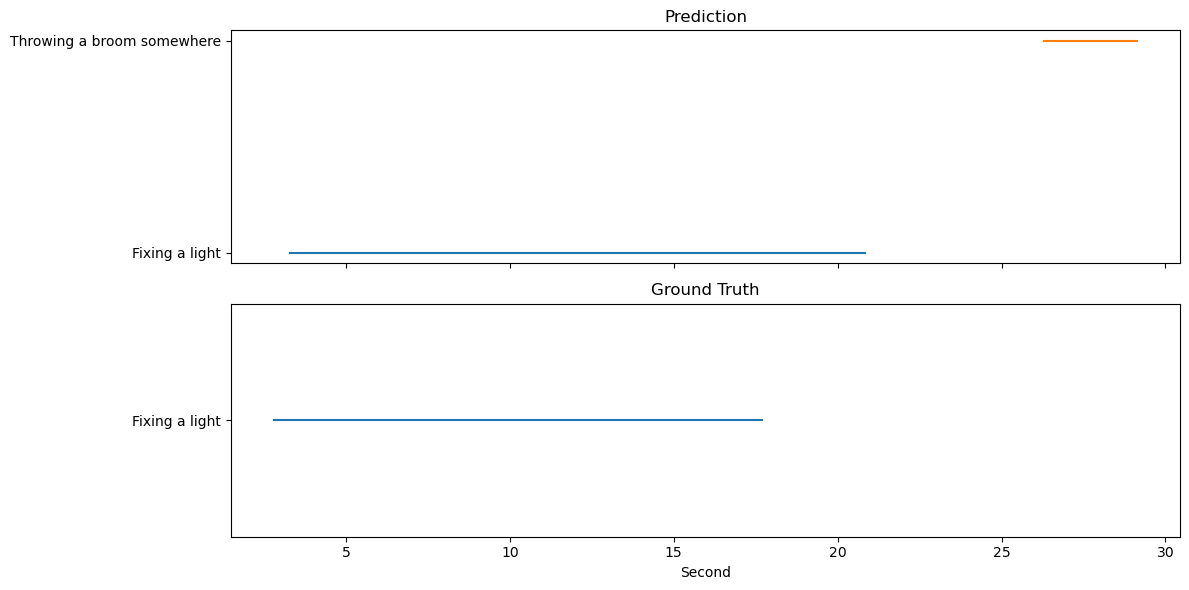

In [177]:
video_id = "0O6RK"
confidence_threshold = 0.04

# predictions for the video
predicted_video = predictions_df[(predictions_df['video_id'] == video_id) & (predictions_df['score'] > confidence_threshold)]
# ground truth for the video
video = gt_df_sample[gt_df_sample['video_id'] == video_id]

# Plot predictions against ground truth
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for _, row in predicted_video.iterrows():
  ax[0].plot([row['start'], row['end']], [row['label']] * 2)
ax[0].set_title('Prediction') 
  
for _, row in video.iterrows():
  ax[1].plot([row['start'], row['end']], [row['label']] * 2)
ax[1].set_title('Ground Truth')

plt.xlabel('Second')  
plt.tight_layout()
plt.show()

# Overlapping Analysis

In [178]:
with open('charades_sample.json', 'r') as f:
  gt = json.load(f)
  
rows_gt = []
for video_id, info in gt['database'].items():
  duration = info['duration']
  subset = info['subset']
  for s in info['annotations']:
    rows_gt.append({
      'video_id': video_id,
      'duration': duration,
      'subset': subset,
      'start': s['segment'][0],
      'end': s['segment'][1],
      'label': s['label']
    })

gt_df = pd.DataFrame(rows_gt)
gt_df.head()

,video_id,duration,subset,start,end,label
0,028CE,20.00,training,2.0,11.0,Fixing a vacuum
1,03EW0,31.12,training,0.0,2.6,Throwing a box somewhere
2,06EDS,35.46,training,23.6,36.0,Making a sandwich
3,08AQS,32.33,training,29.1,33.0,Throwing a box somewhere
4,08LOY,28.04,testing,5.7,21.9,Fixing a light
